<a href="https://colab.research.google.com/github/luciacubero20/Practicas_Redes_Neuronales_LuciaCubero/blob/main/Practica_05_Luc%C3%ADaCubero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>05. Ajuste de la red</b></font>


### Ejercicio 01

Crea un MLP que realice una clasificación razonable, para ello utiliza las estrategias ***que consideres oportunas***.

- Crear conjuntos de entrenamiento, dev y test
- Ejecuta la red sobre una GPU
- Buscar parámetros con Optuna
- Usar regularizaciones
- etc.

In [21]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Comprobamos si tenemos GPU
print(torch.cuda.is_available())

True


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [24]:
class Flatten(object):
    def __call__(self, tensor):
        # Aplanar la imagen a un vector de 784 píxeles
        return tensor.view(-1)


transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte la imagen a tensor
    transforms.Normalize((0.5,), (0.5,)),  # Normalización
    transforms.Lambda(lambda x: x.view(-1)) # Aplanar las imágenes a un vector de 784 píxeles
    # Flatten()  # Aplanar las imágenes a un vector de 784 píxeles
])


train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

generator = torch.Generator().manual_seed(2006)
train_dataset, dev_dataset = random_split(train_data, [50000, 10000], generator=generator)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

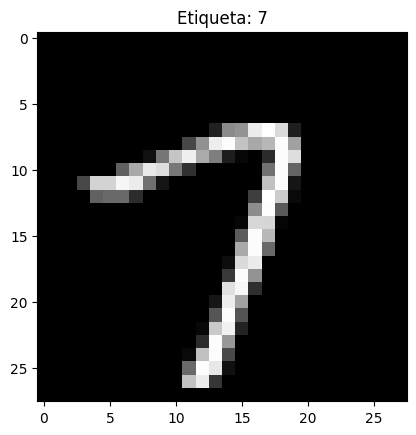

In [25]:
# Obtener una imagen y su etiqueta
image, label = train_dataset[5]  # Obtener la primera imagen del conjunto de entrenamiento

# Visualizar la imagen
plt.imshow(image.view(28,28), cmap='gray')  # .squeeze() elimina la dimensión de los canales (1,28,28 -> 28,28)
plt.title(f"Etiqueta: {label}")
plt.show()

In [26]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size_1=128, hidden_size_2=64, output_size=10, dropout_p=0.2):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            # Capa de entrada a capa oculta 1
            nn.Linear(input_size, hidden_size_1), # Hacemos el sumatorio
            nn.BatchNorm1d(hidden_size_1), # Normalización después de la capa 1
            nn.ReLU(),              # Aplicamos la función de activacion
            nn.Dropout(p=dropout_p),  # Dropout después de la capa oculta 1

            # Capa oculta 1 a capa oculta 2
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.BatchNorm1d(hidden_size_2),  # Normalización después de la capa 2
            nn.ReLU(),
            nn.Dropout(p=dropout_p),  # Dropout después de la capa oculta 2

            # Capa oculta 2 a capa de salida
            nn.Linear(hidden_size_2, output_size)
        )

        # Hacemos las incializaciones
        for layer in self.model:
          if isinstance(layer, nn.Linear):
            init.kaiming_uniform_(layer.weight, nonlinearity='relu')

    def forward(self, x):
        output = self.model(x)
        return output

In [27]:
!pip install torcheval
!pip install optuna

In [28]:
import optuna
import torcheval
import torch.optim as optim
from torcheval.metrics import MulticlassAccuracy

In [29]:
def objective(trial):
  learning_rate = trial.suggest_float("learning_rate", 0.001, 0.01, log=True)
  model = MLP().to(device) # envía el modelo a la GPU
  loss_fn = nn.CrossEntropyLoss() # para clasificar 10 clases
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  accuracy = MulticlassAccuracy(num_classes=10).to(device)

  model.train()
    # Entrenamiento simple
  for epoch in range(5):
      for X_batch, y_batch in train_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          optimizer.zero_grad()
          output = model(X_batch)
          loss = loss_fn(output, y_batch)
          loss.backward()
          optimizer.step()

      # Evaluar precisión (usando dev_loader)
  model.eval()
  for X_batch, y_batch in dev_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        accuracy.update(output, y_batch)

  return accuracy.compute().item()



In [30]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)  # Probar 20 combinaciones

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", study.best_params)

[I 2026-03-17 11:31:19,110] A new study created in memory with name: no-name-66f13e9b-8ffb-4ffc-b4bf-05d015cd28b3
[I 2026-03-17 11:32:34,094] Trial 0 finished with value: 0.9750000238418579 and parameters: {'learning_rate': 0.00630855692830562}. Best is trial 0 with value: 0.9750000238418579.
[I 2026-03-17 11:33:43,587] Trial 1 finished with value: 0.972599983215332 and parameters: {'learning_rate': 0.0011516659937029342}. Best is trial 0 with value: 0.9750000238418579.
[I 2026-03-17 11:34:53,340] Trial 2 finished with value: 0.9772999882698059 and parameters: {'learning_rate': 0.0036724545886682005}. Best is trial 2 with value: 0.9772999882698059.
[I 2026-03-17 11:36:05,632] Trial 3 finished with value: 0.9745000004768372 and parameters: {'learning_rate': 0.004240086640827918}. Best is trial 2 with value: 0.9772999882698059.
[I 2026-03-17 11:37:16,312] Trial 4 finished with value: 0.9765999913215637 and parameters: {'learning_rate': 0.0012041435546085802}. Best is trial 2 with value: 

Mejores hiperparámetros: {'learning_rate': 0.0036724545886682005}


In [31]:
# el mejor learning rate que encontró Optuna
best_lr = study.best_params["learning_rate"]


# se crea el modelo definitivo y se manda a la GPU
final_model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()

# optimizador con regularización l2
optimizer = optim.Adam(final_model.parameters(), lr=best_lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)


acc = MulticlassAccuracy(num_classes=10).to(device)

num_epochs = 20
loss_list, acc_list = [], []

for epoch in range(num_epochs):
    final_model.train()

    for batch_idx, (features, targets) in enumerate(train_loader):
        features, targets = features.to(device), targets.to(device)

        # forward
        output = final_model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/020 | Batch 000/782 | Train Loss: 2.85 | Accuracy: 0.11
Epoch: 001/020 | Batch 100/782 | Train Loss: 0.37 | Accuracy: 0.81
Epoch: 001/020 | Batch 200/782 | Train Loss: 0.40 | Accuracy: 0.85
Epoch: 001/020 | Batch 300/782 | Train Loss: 0.41 | Accuracy: 0.87
Epoch: 001/020 | Batch 400/782 | Train Loss: 0.24 | Accuracy: 0.88
Epoch: 001/020 | Batch 500/782 | Train Loss: 0.39 | Accuracy: 0.89
Epoch: 001/020 | Batch 600/782 | Train Loss: 0.07 | Accuracy: 0.90
Epoch: 001/020 | Batch 700/782 | Train Loss: 0.39 | Accuracy: 0.90
Epoch: 002/020 | Batch 000/782 | Train Loss: 0.14 | Accuracy: 0.90
Epoch: 002/020 | Batch 100/782 | Train Loss: 0.20 | Accuracy: 0.91
Epoch: 002/020 | Batch 200/782 | Train Loss: 0.07 | Accuracy: 0.91
Epoch: 002/020 | Batch 300/782 | Train Loss: 0.10 | Accuracy: 0.92
Epoch: 002/020 | Batch 400/782 | Train Loss: 0.20 | Accuracy: 0.92
Epoch: 002/020 | Batch 500/782 | Train Loss: 0.18 | Accuracy: 0.92
Epoch: 002/020 | Batch 600/782 | Train Loss: 0.07 | Accuracy: 

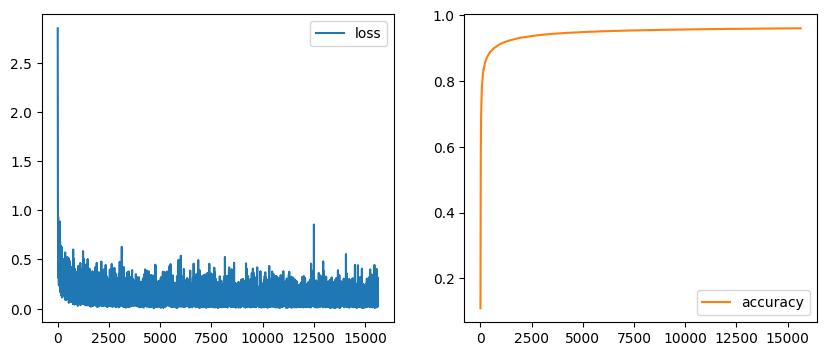

In [32]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.plot(loss_list)
plt.legend(['loss'])


plt.subplot(1, 2, 2)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])


plt.show()

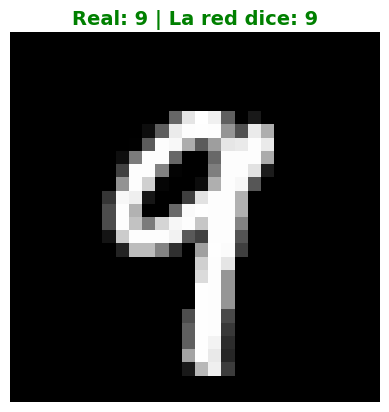

In [33]:
import random
import matplotlib.pyplot as plt
import torch


final_model.eval()

indice_al_azar = random.randint(0, len(test_dataset) - 1)
imagen, etiqueta_real = test_dataset[indice_al_azar]


imagen_lista = imagen.unsqueeze(0).to(device)


with torch.no_grad():
    salida = final_model(imagen_lista)
    prediccion = salida.argmax(dim=1).item()


plt.imshow(imagen.view(28, 28), cmap='gray')

color = 'green' if prediccion == etiqueta_real else 'red'
plt.title(f"Real: {etiqueta_real} | La red dice: {prediccion}", color=color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()